This notebook uses the NASA CMAPSS (Commercial Modular Aero-Propulsion System Simulation) FD001 dataset. 

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

*Incase you dont have the libraries uncomment and run the cell below then the above cell*

In [94]:
# pip install pandas
# pip install numpy
# pip install scikit-learn
# pip install xgboost
# pip install torch

Each row represents one operating cycle of a turbofan engine. The dataset contains 26 columns which are: engine ID, cycle number, 3 operational settings, and 21 sensor measurements. To get an idea how the data structure looks, we have used .head() and .shape command

In [95]:
col_names = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f'sensor{i}' for i in range(1,22)]
df = pd.read_csv(r"C:\Users\DELL\Downloads\CMAPSSData (1)\train_FD001.txt" , sep=r'\s+', header= None, names=col_names)
print(df.shape)
print(df.head())

(20631, 26)
   engine_id  cycle  setting1  setting2  setting3  sensor1  sensor2  sensor3  \
0          1      1   -0.0007   -0.0004     100.0   518.67   641.82  1589.70   
1          1      2    0.0019   -0.0003     100.0   518.67   642.15  1591.82   
2          1      3   -0.0043    0.0003     100.0   518.67   642.35  1587.99   
3          1      4    0.0007    0.0000     100.0   518.67   642.35  1582.79   
4          1      5   -0.0019   -0.0002     100.0   518.67   642.37  1582.85   

   sensor4  sensor5  ...  sensor12  sensor13  sensor14  sensor15  sensor16  \
0  1400.60    14.62  ...    521.66   2388.02   8138.62    8.4195      0.03   
1  1403.14    14.62  ...    522.28   2388.07   8131.49    8.4318      0.03   
2  1404.20    14.62  ...    522.42   2388.03   8133.23    8.4178      0.03   
3  1401.87    14.62  ...    522.86   2388.08   8133.83    8.3682      0.03   
4  1406.22    14.62  ...    522.19   2388.04   8133.80    8.4294      0.03   

   sensor17  sensor18  sensor19  senso

To explore the dataset, we will take the mean of the sensor 2 which gives us the temperature for each engineID. EngineID with number of cycles over 200 can be easily taken into new dataframe to get a better understanding of the highest performing engine and the ones with less than 200 have been filtered out.

In [96]:
mean  = df.groupby('engine_id').sensor2.mean()
print(mean)
max_cycle  = df.groupby('engine_id').cycle.max().sort_values(ascending=True)
over_200 = max_cycle[max_cycle>=200]
print(over_200)
new_df = df[df['engine_id'].isin(over_200.index)]
print(new_df.shape)
print(new_df.head())

engine_id
1      642.621042
2      642.435226
3      642.543743
4      642.662381
5      642.451970
          ...    
96     642.629821
97     642.522624
98     642.584872
99     642.611081
100    642.741250
Name: sensor2, Length: 100, dtype: float64
engine_id
33     200
100    200
9      201
66     202
22     202
97     202
15     207
43     207
71     208
16     209
76     210
52     213
73     213
88     213
51     213
72     213
82     214
47     214
49     215
41     216
89     217
10     222
75     229
25     230
59     231
78     231
48     231
20     234
31     234
11     240
81     240
46     256
54     257
94     258
7      259
84     267
5      269
56     275
17     276
86     278
95     283
64     283
2      287
83     293
67     313
96     336
92     341
69     362
Name: cycle, dtype: int64
(11604, 26)
     engine_id  cycle  setting1  setting2  setting3  sensor1  sensor2  \
192          2      1   -0.0018    0.0006     100.0   518.67   641.89   
193          2      2    0.

Now we will be calculating the RUL (Remaining Useful Life) for the engines. This can be done by taking the difference between max cycles of an engine and the current cycle. This tells us how many cycles before the engine fails to perform.

In [97]:
max_cycle = df.groupby('engine_id').cycle.max()
df['RUL'] = df.engine_id.map(max_cycle) - df['cycle']
df[['engine_id' , 'cycle', 'RUL']].head(10)

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [98]:
x = df[[f'sensor{i}' for i in range(1,22)]]
y = df['RUL']
x.shape
# y.shape

(20631, 21)

Now we will use Random Forest Regressor to train the model with 100 decision trees from which the test size will be 20 and training size will be 80. This means that the model will train itself using only 80% of the data and the rest 20% will be unknown on which we will be conducting the test to check how accurate our model is. Random Forest is chosen because it combines multiple decision trees and averages their predictions, making it more robust and accurate than a single tree.

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)
print(x_train.shape)
print(x_test.shape)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

(16504, 21)
(4127, 21)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Now we will test the model to check whether the output it is giving is accurate enough. For this we will use the rmse(root mean square error) and then plot this comparing the tested data with the predicted data.

In [100]:
y_pred = model.predict(x_test)
# y_pred.shape
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

41.38695987430714


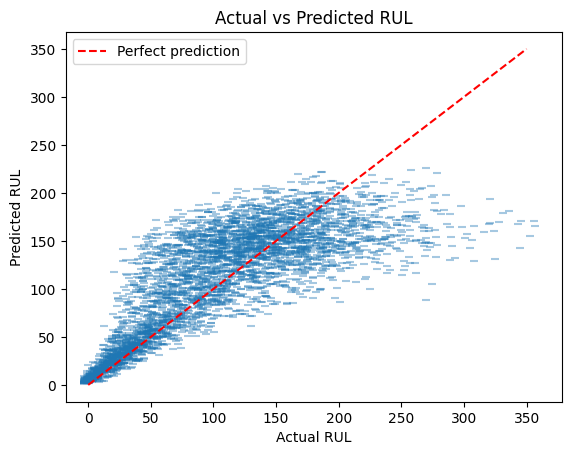

In [101]:
plt.scatter(y_test, y_pred, marker = 0, alpha = 0.4)
plt.plot([0, 350], [0, 350], 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Actual vs Predicted RUL')
plt.legend()
plt.show()

The model achieved an RMSE of 41.38 cycles. The model performs well at predicting low RUL values (engines close to failure) but underestimates high RUL values which is visible in the scatter plot deviation from the ideal diagonal. To improve our model we will now take out some of the data which might not be affecting the RUL value and be the cause for the errors. This can be done using the feature_importances which shows which data is affecting the predicting and testing data the most. 

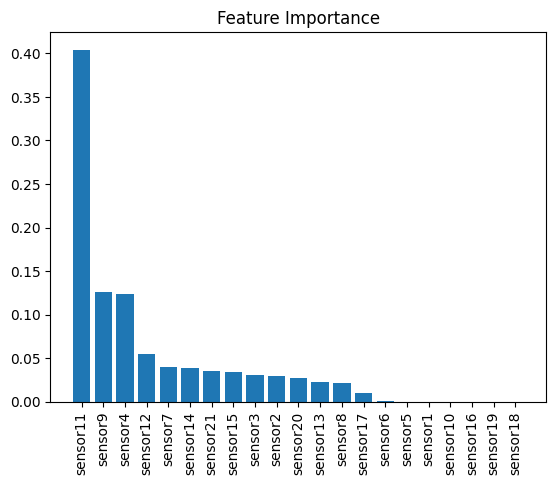

In [102]:
imp = model.feature_importances_
imp_series = pd.Series(imp, index= x.columns)
imp_series_sort = imp_series.sort_values(ascending=False)
plt.bar(imp_series_sort.index, imp_series_sort.values)
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()


Sensor 11 (bypass ratio) dominates with 40% importance, followed by sensors 9, 4, and 12. Several sensors (1, 5, 6, 16, 18, 19) contribute almost nothing to predictions. This insight can be used to simplify the model by removing low importance sensors.

### TRAIN THE MODEL NOW USING XGBOOST

43.37477907679689


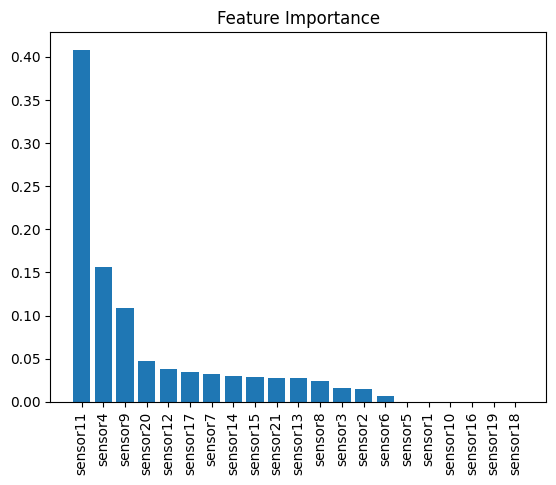

In [103]:
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred_xg = model.predict(x_test)
rmse_xg = np.sqrt(mean_squared_error(y_test, y_pred_xg))
print(rmse_xg)

imp_xg = model.feature_importances_
imp_series_xg = pd.Series(imp_xg, index= x.columns)
imp_series_sort_xg = imp_series_xg.sort_values(ascending=False)
plt.bar(imp_series_sort_xg.index, imp_series_sort_xg.values)
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

Interestingly we did not better result with XGBOOST so now we will be eliminating the unusefull sensor data and try getting better data.

## Feature Selection - Using Top Sensors Only
Based on feature importance analysis, we retrain both models using only the top sensors to see if removing low-importance sensors improves accuracy.

In [104]:
x_top = df[[f'sensor{i}' for i in [11, 4, 9, 20, 7, 17, 14, 15, 21, 13, 8, 3, 2, 12]]]
x_top.shape
x_train_top, x_test_top, y_train_top, y_test_top = train_test_split(x_top, y, test_size=0.2, random_state= 42)
# y.shape
x_train_top.head()

,sensor11,sensor4,sensor9,sensor20,sensor7,sensor17,sensor14,sensor15,sensor21,sensor13,sensor8,sensor3,sensor2,sensor12
6244,47.43,1406.22,9053.69,38.87,552.91,394,8133.12,8.4314,23.3300,2388.11,2388.16,1590.83,642.50,521.53
9380,47.42,1404.90,9078.73,38.84,554.30,390,8154.88,8.3808,23.3267,2388.03,2388.01,1593.76,642.24,522.76
6105,47.17,1402.17,9047.77,38.99,553.31,393,8138.43,8.4055,23.2714,2388.11,2388.02,1579.35,642.41,521.81
15825,47.33,1404.95,9057.49,38.92,554.29,392,8143.82,8.4213,23.4385,2388.00,2388.03,1582.62,642.77,522.20
19025,47.54,1405.20,9046.89,38.77,553.00,393,8129.89,8.4235,23.2681,2388.16,2388.17,1587.27,642.69,521.48


41.352588318621386
43.3793197371671


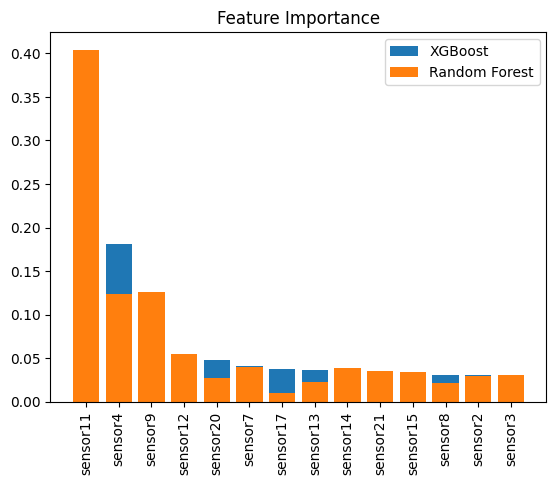

In [105]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(x_train_top, y_train_top)
y_pred_rf = model_rf.predict(x_test_top)
rmse_rf = np.sqrt(mean_squared_error(y_test_top, y_pred_rf))
print(rmse_rf)

imp_new = model_rf.feature_importances_
imp_series_new = pd.Series(imp_new, index= x_top.columns)
imp_series_sort_new = imp_series_new.sort_values(ascending=False)



model_xg = XGBRegressor(n_estimators=100, random_state=42)
model_xg.fit(x_train_top, y_train_top)
y_pred_xg = model_xg.predict(x_test_top)
rmse_xg = np.sqrt(mean_squared_error(y_test_top, y_pred_xg))
print(rmse_xg)

imp_xg_new = model_xg.feature_importances_
imp_series_xg_new = pd.Series(imp_xg_new, index= x_top.columns)
imp_series_sort_xg_new = imp_series_xg_new.sort_values(ascending=False)


plt.bar(imp_series_sort_xg_new.index, imp_series_sort_xg_new.values)
plt.bar(imp_series_sort_new.index, imp_series_sort_new.values)
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.legend(['XGBoost', 'Random Forest'])
plt.show()

This concludes that only top 3 sensors hurts performance significantly so now we will try to adjust the eliminators to 300 and the max depth to 10 to check if we can get a better rmse value.

Since Randomforest is performing better (low rmse) we'll first focus on that only.

In [106]:
model_rf = RandomForestRegressor(n_estimators=300, max_depth= 10, random_state=42)
model_rf.fit(x_train_top, y_train_top)
y_pred_rf = model_rf.predict(x_test_top)
rmse_rf = np.sqrt(mean_squared_error(y_test_top, y_pred_rf))
print(rmse_rf)


41.082258572413835


This gave us very marginal difference so now we will be looking at a different approach and try to cap the y values 

In [119]:
x_top = df[[f'sensor{i}' for i in [11, 4, 9, 20, 7, 17, 14, 15, 21, 13, 8, 3, 2, 12]]]
x_top.shape

y_capped = y.clip(upper = 125)
x_train_top, x_test_top, y_train_top, y_test_top = train_test_split(x_top, y_capped, test_size=0.2, random_state= 42)

model_rf = RandomForestRegressor(n_estimators=300, max_depth= 10, random_state=42)
model_rf.fit(x_train_top, y_train_top)
y_pred_rf = model_rf.predict(x_test_top)
rmse_rf = np.sqrt(mean_squared_error(y_test_top, y_pred_rf))
print(rmse_rf)


18.593434003390453


In [121]:
import pickle
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(model_rf, f)
print('Model saved!')

Model saved!


This showed significant inprovement than the previous results, lets now compare it with the XGboost regressor to see if that gives even better results.

In [108]:
model_rf = XGBRegressor(n_estimators=300, max_depth= 10, random_state=42)
model_rf.fit(x_train_top, y_train_top)
y_pred_rf = model_rf.predict(x_test_top)
rmse_rf = np.sqrt(mean_squared_error(y_test_top, y_pred_rf))
print(rmse_rf)


19.89463747701367


To summarize all the results we have obtained.

| Model | RMSE |
|-------|------|
| RF Baseline | 41.38 |
| XGBoost Baseline | 43.37 |
| RF Tuned (200 trees, depth 10) | 41.09 |
| RF Capped RUL  | **18.59** |
| XGBoost Capped RUL | 19.89 |

The winner is very clear!!

## LSTM Model
Now lets start with LSTM (Long Short Term Memory) to capture transient patterns in engine degradation.

Lets use the sliding window approach and take a seq_length of 30 cycles(most commonly taken in paper) to predict the RUL

In [109]:
def create_sequences(df, seq_length=30):
    x_seq, y_seq = [], []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id]
        sensors = engine_data[[f'sensor{i}' for i in [11, 4, 9, 20, 7, 17, 14, 15, 21, 13, 8, 3, 2, 12]]].values
        rul = engine_data['RUL'].clip(upper=125).values
        for i in range(len(sensors) - seq_length):
            x_seq.append(sensors[i:i+seq_length])
            y_seq.append(rul[i+seq_length])
    return np.array(x_seq), np.array(y_seq)

In [110]:
x_seq, y_seq = create_sequences(df, seq_length=30)
print(x_seq.shape)
print(y_seq.shape)

(17631, 30, 14)
(17631,)


As done previously, now splitting and trainng the data

In [111]:
x_train_seq, x_test_seq, y_train_seq, y_test_seq = train_test_split(
    x_seq, y_seq, test_size=0.2, random_state=42)

x_train_tensor = torch.FloatTensor(x_train_seq)
x_test_tensor = torch.FloatTensor(x_test_seq)
y_train_tensor = torch.FloatTensor(y_train_seq)
y_test_tensor = torch.FloatTensor(y_test_seq)

print(x_train_tensor.shape)

torch.Size([14104, 30, 14])


In [112]:
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=14, hidden_size=64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

model_lstm = LSTMModel()
print(model_lstm)

LSTMModel(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Now the model is built, lets setup the training loop.

In [113]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

dataset = TensorDataset(x_train_tensor, y_train_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [114]:
epochs = 20
for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        predictions = model_lstm(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}')

Epoch 5/20, Loss: 2325.1445
Epoch 10/20, Loss: 1749.6080
Epoch 15/20, Loss: 1744.0359
Epoch 20/20, Loss: 1744.0338


Since the loss has flattened, the model is now converged. Lets check the rmse now

In [115]:
model_lstm.eval()
with torch.no_grad():
    y_pred_lstm = model_lstm(x_test_tensor)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm.numpy()))
    print('LSTM RMSE:', rmse_lstm)

LSTM RMSE: 41.89118011801157


Interestingly this is not better but is similar to the RF initial values, so lets cap this too at RUL 125

In [116]:
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[[f'sensor{i}' for i in [11, 4, 9, 20, 7, 17, 14, 15, 21, 13, 8, 3, 2, 12]]] = scaler.fit_transform(
    df[[f'sensor{i}' for i in [11, 4, 9, 20, 7, 17, 14, 15, 21, 13, 8, 3, 2, 12]]])

In [117]:
def create_sequences(df_scaled, seq_length=30):
    x_seq, y_seq = [], []
    for engine_id in df_scaled['engine_id'].unique():
        engine_data = df_scaled[df_scaled['engine_id'] == engine_id]
        sensors = engine_data[[f'sensor{i}' for i in [11, 4, 9, 20, 7, 17, 14, 15, 21, 13, 8, 3, 2, 12]]].values
        rul = engine_data['RUL'].clip(upper=125).values
        for i in range(len(sensors) - seq_length):
            x_seq.append(sensors[i:i+seq_length])
            y_seq.append(rul[i+seq_length])
    return np.array(x_seq), np.array(y_seq)

x_train_seq, x_test_seq, y_train_seq, y_test_seq = train_test_split(
    x_seq, y_seq, test_size=0.2, random_state=42)

x_train_tensor = torch.FloatTensor(x_train_seq)
x_test_tensor = torch.FloatTensor(x_test_seq)
y_train_tensor = torch.FloatTensor(y_train_seq)
y_test_tensor = torch.FloatTensor(y_test_seq)

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=14, hidden_size=128, num_layers=2, batch_first=True)
        self.fc = nn.Linear(128, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

model_lstm = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

dataset = TensorDataset(x_train_tensor, y_train_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

epochs = 30
for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        predictions = model_lstm(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}')

model_lstm.eval()
with torch.no_grad():
    y_pred_lstm = model_lstm(x_test_tensor)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm.numpy()))
    print('LSTM RMSE:', rmse_lstm)

Epoch 5/30, Loss: 1758.8769
Epoch 10/30, Loss: 1744.9202
Epoch 15/30, Loss: 1744.4279
Epoch 20/30, Loss: 1743.6961
Epoch 25/30, Loss: 1746.6073
Epoch 30/30, Loss: 1745.3369
LSTM RMSE: 41.891012563481326


In the above code we can try to vary the epoch and the hidden_size but it seems the model is stuck at 41.891021 value